
# I'm feeling great... or is it the wind?

Sometimes, on a bike, you feel particularly fit. The road unfolds before your eyes, effortlessly. You're proud of your physical condition and performance. But could the wind be playing a role?

This notebook will show you how to relive one of your rides to analyze the influence of the wind on your effort.

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Thu Dec  4 14:46:47 2025

@author: jacme
"""
from datetime import timedelta, datetime
from zoneinfo import ZoneInfo
import os
import matplotlib.pylab as plt

from refwindcycle.core import Simulator
from refwindcycle.core.bike_physics import estimate_P0_from_v0
from refwindcycle.core.cyclist_params import CyclistBehavior



from refwindcycle.weather import WeatherProvider
from refwindcycle.weather.roughness_provider import RoughnessProvider
from refwindcycle.weather.grib_finder import build_grib_list
from refwindcycle.analysis import RouteAnalyzer
from refwindcycle.analysis.anareswind import (
    plot_segments_evolution,
    compare_scenarios,
    print_summary_statistics,
    plot_wind_rose,
    detect_outliers,
    detect_real_climbs,
    smooth_segments,
    plot_elevation_profile,
)


from refwindcycle.visualization.interactive_map import create_interactive_map

## 1.Loading and pre-processing the gpx file 


We define the GPX file corresponding to the route already completed. This GPX file must include timestamps.

The GPX file used for this example is located in the example directory. Replace it with your own route!

The GPX file is preprocessed. We filter out all stops made during the route.

Since the GPX file contains timestamps, we obtain the start date and duration of the route.

In [2]:
origin_tz = ZoneInfo("Europe/Paris")

pathbase="S3"
filegpx=pathbase+".gpx"

# LOAD GPX
analyzer = RouteAnalyzer() 
gpx_result = analyzer.process_gpx(filegpx, filter_stops_flag=True)

if gpx_result.has_timestamps:
    t_start=gpx_result.t_start.astimezone(origin_tz)
    st_start=t_start.strftime("%Y-%m-%d %H:%M:%S")
    ct_start=t_start.strftime("%b-%d")
    segments = gpx_result.segments
    stats = gpx_result.stats
    duration=gpx_result.duration
else:
    print("⚠️  Le fichier GPX ne contient pas de timestamps !")
    raise ValueError("Le fichier GPX doit contenir des timestamps pour le replay.")
print (f"--> GPX file loaded and processed. Starting date: {st_start} - Duration: {duration} - Elevation gain: {stats['deniv_pos_final']:.0f} m")



  NETTOYAGE GPX: S3.gpx
[1/6] Chargement du fichier GPX...
[2/6] Création des segments (smooth=True)...
      3638 segments créés, denivelé: 430.7 m
[3/6] Détection des bruits GPS...
      ⚠ 1 segments aberrants détectés
      Suppression des bruits...
[4/6] Fusion des segments courts (min_dist=50.0m)...
      1563 segments fusionnés
[5/6] Filtrage des segments arrêtés (v < 1 m/s)...
      30 segments arretes filtres
[6/6] Résumé du traitement:
      Segments: 3638 -> 2044
      Distance: 114.397km -> 113.881km
      Denivelé: 430.7m -> 428.2m
      Rectangle SN: (47, 49), EW: (1, 3)
      Timestamps: 2025-03-29 09:22:48 UTC → durée: 6:06:40

--> GPX file loaded and processed. Starting date: 2025-03-29 10:22:48 - Duration: 6:06:40 - Elevation gain: 428 m


## 2.Building the wind model

### 2.1. Selecting the Weather model

The weather model by default is GFS. 

You can change it to IFS by setting the WEATHER_MODEL variable to "IFS". 

Note that with the IFS model when the departure times are in the past I encounterad some problems 
with  grib files without gust data. GFS last forecast are good,GFS downloads are very reliable, so I encourage you to use GFS for replays in the past.


### 2.1. Selecting the Grib files 

We use the build_grib_list function to build the list of grib files needed for the  departure time and the duration including a margin .

In [8]:
WEATHER_MODEL='GFS'
# Define the directory used to store GRIB files
hdir = "~/data"  # GRIB files stored in home/data by default
duration_hours = int(gpx_result.duration.total_seconds() / 3600) + 1
print (f"\nBuilding grib liste  {st_start} + {duration_hours}h (model {WEATHER_MODEL})...")
gribs_list = build_grib_list(hdir, t_start, 3, duration_hours,model=WEATHER_MODEL)
print(f"Avaliable grib : {len(gribs_list)} files for  {WEATHER_MODEL} - Initialization :")
weather = WeatherProvider(gribs_list, bcache=True,model=WEATHER_MODEL)
print("--> Weather model initialization completed.")
mygrib = weather.grib


Building grib liste  2025-03-29 10:22:48 + 7h (model GFS)...
Avaliable grib : 5 files for  GFS - Initialization :
--> Weather model initialization completed.


In [ ]:
import psutil
psutil.virtual_memory()


svmem(total=15523971072, available=5902274560, percent=62.0, used=9621696512, free=828612608, active=6792806400, inactive=5214818304, buffers=198049792, cached=4682743808, shared=257601536, slab=1373286400)

In [9]:
CdA = 0.420
Cr = 0.00430
M = 69
mon_profil=CyclistBehavior(uphill='realistic', downhill='realistic', corner='realistic')
sim_replay = Simulator( mygrib, behavior=mon_profil, CdA=CdA, Cr=Cr, m=M)
results_timestamps = sim_replay.simulate_replay( segments)
results = results_timestamps 
if results.power.P0_calibrated is not None:
        P0 = results.power.P0_calibrated

In [6]:

print_summary_statistics(results_timestamps, "Avec vent")


  STATISTIQUES - Avec vent

📏 Distance totale: 113.88 km
⏱️  Temps total: 04:13:35
🚴  Vitesse moyenne: 26.95 km/h (max=43.43 km/h)
⚡  Puissance moyenne: 103.6 W

💨 Vent (TWS et TWD):
   Moyen: 11.97 km/h - Direction: 350° (N)
   Min: 9.58 km/h
   Max: 13.28 km/h

💨 Rafales (Gust):
   Moyenne: 15.90 km/h
   Min: 14.65 km/h (au km 113.86)
   Max: 16.45 km/h (au km 71.60)

⛰️ Pente terrain:
   Moyenne: 0.12 %
   Min (lissé 100m): -8.62% (au km 10.69)
   Max (lissé 100m): 9.50% (au km 25.40)
   Dénivelé positif: 428 m
   Dénivelé négatif: -394 m

🌬️ Pente virtuelle (vent):
   Moyenne: -1.28%
   Min (lissé 100m): -3.14% (au km 85.80)
   Max (lissé 100m): 2.01% (au km 91.43)
   Dénivelé virtuel positif: 51 m
   Dénivelé virtuel négatif: -1658 m

📊 Pente effective (terrain + vent):
   Moyenne: -1.16%
   Min (lissé 100m): -8.91% (au km 7.12)
   Max (lissé 100m): 9.34% (au km 25.23)
   Dénivelé effectif positif: 479 m
   Dénivelé effectif négatif: -2052 m

🎯 Vent le long de la trajectoire:
   

In [7]:
sim_nowind = Simulator(None, behavior=mon_profil, CdA=CdA, Cr=Cr, m=M)
results_nowind = sim_nowind.simulate_future( segments, t_start, P0=P0)

In [8]:
print_summary_statistics(results_nowind, "Avec vent")


  STATISTIQUES - Avec vent

📏 Distance totale: 113.88 km
⏱️  Temps total: 05:06:08
🚴  Vitesse moyenne: 22.32 km/h (max=43.31 km/h)
⚡  Puissance moyenne: 107.5 W

💨 Vent (TWS et TWD):
   Moyen: 0.00 km/h - Direction: 0° (N)
   Min: 0.00 km/h
   Max: 0.00 km/h

💨 Rafales (Gust):
   Moyenne: 0.00 km/h
   Min: 0.00 km/h (au km 113.86)
   Max: 0.00 km/h (au km 113.86)

⛰️ Pente terrain:
   Moyenne: 0.12 %
   Min (lissé 100m): -8.62% (au km 10.69)
   Max (lissé 100m): 9.50% (au km 25.40)
   Dénivelé positif: 428 m
   Dénivelé négatif: -394 m

🌬️ Pente virtuelle (vent):
   Moyenne: 0.00%
   Min (lissé 100m): 0.00% (au km 0.01)
   Max (lissé 100m): 0.00% (au km 0.01)
   Dénivelé virtuel positif: 0 m
   Dénivelé virtuel négatif: 0 m

📊 Pente effective (terrain + vent):
   Moyenne: 0.12%
   Min (lissé 100m): -8.62% (au km 10.69)
   Max (lissé 100m): 9.50% (au km 25.40)
   Dénivelé effectif positif: 428 m
   Dénivelé effectif négatif: -394 m

🎯 Vent le long de la trajectoire:
   Vent de face: 0.

In [9]:
# Lissage des segments pour améliorer la lisibilité des graphiques
print("\nLissage des données pour les graphiques (fenêtre=7)...")
results_nowind_smooth = smooth_segments(results_nowind.get_segments(), window=17)
results_timestamps_smooth = smooth_segments(results_timestamps.get_segments(), window=17)


Lissage des données pour les graphiques (fenêtre=7)...


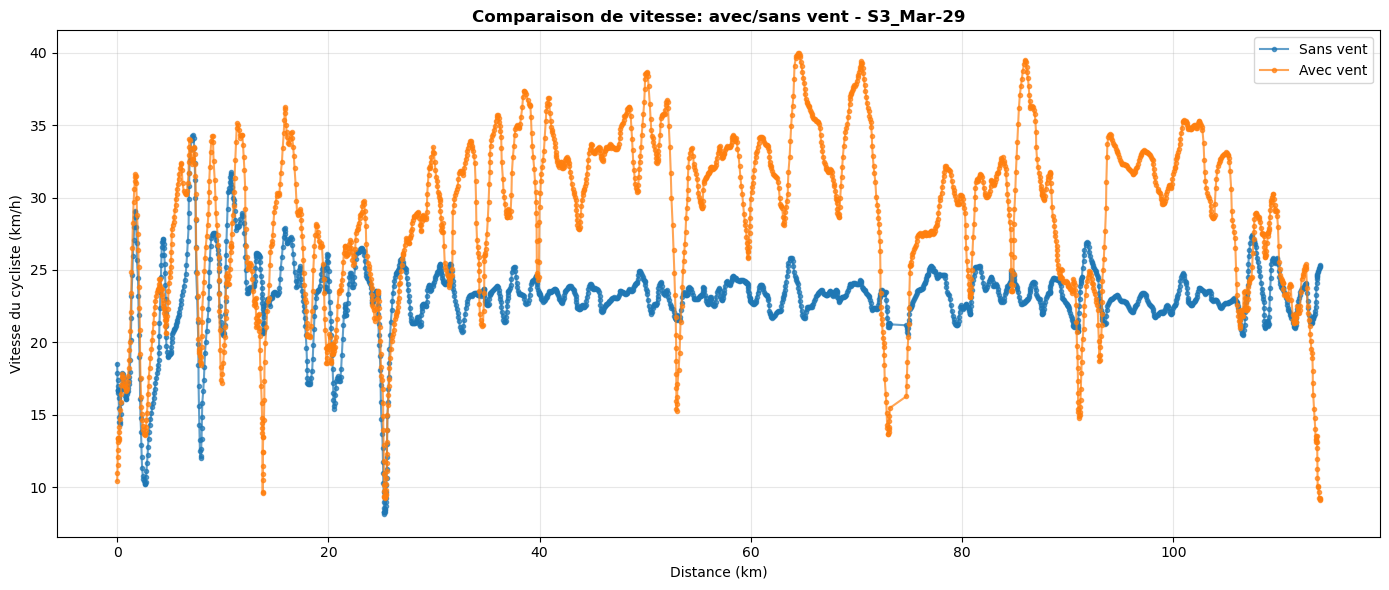

In [10]:
# 2. Comparaison vitesse avec/sans vent
fig2, ax2 = compare_scenarios(
    [results_nowind_smooth, results_timestamps_smooth],
    labels=['Sans vent', 'Avec vent'],
    attribute='speed_m_s',
    x_axis='distance',
    title=f'Comparaison de vitesse: avec/sans vent - {pathbase}_{ct_start}'
)
plt.show()